In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in data
cells = pd.read_csv('../data/cd34_umap_patient_updated.csv', index_col = 0)
cells.columns

Index(['V1', '209Bi_CD45', 'Center', '161Dy_CD274_PDL1', '162Dy_CD80',
       'Event_length', '157Gd', '113In_CD45', '191Ir_DNA1', '193Ir_DNA2',
       '175Lu_STAT1_PE', '104Pd_CD45', '106Pd_CD45', '108Pd_CD45',
       '110Pd_CD45', '141Pr_CD196_CCR6', '194Pt_Cisplatin1',
       '195Pt_Cisplatin2', '147Sm_NKG2DFc_Cy5', '159Tb_CD90', '89Y_CD45',
       'Time', 'FileName', 'FileNo', 'Date', 'Patient_ID', 'Timepoint',
       'Batch_Control', 'Reference', 'Batch_Control_Type', 'Healthy',
       'Disease', 'Batch', '7_month_response', '12_month_response',
       '163Dy_CD117_asinh_coarseAlign_fineAlign',
       '164Dy_CD172ab_SIRPab_asinh_coarseAlign_fineAlign',
       '166Er_CD34_asinh_coarseAlign_fineAlign',
       '167Er_CD38_asinh_coarseAlign_fineAlign',
       '168Er_Ki67_asinh_coarseAlign_fineAlign',
       '170Er_CD3_asinh_coarseAlign_fineAlign',
       '151Eu_CD123_asinh_coarseAlign_fineAlign',
       '153Eu_CD68_asinh_coarseAlign_fineAlign',
       '155Gd_CD303_asinh_coarseAlign_fi

In [3]:
# Read in a file which details the cell type of each cluster
cluster_result = pd.read_csv('../data/cd34_annotation.csv')
cell_type_dict = dict(zip(cluster_result['cluster'], cluster_result['cell_type']))
cell_type_dict

{1: 'CD33 HSC',
 2: 'Myeloid precursor',
 3: 'HSC',
 4: 'Myeloid precursor',
 5: 'Myeloid precursor',
 6: 'CD56 pos',
 7: 'CD56 pos',
 8: 'Myeloid precursor',
 9: 'Myeloid precursor',
 10: 'Myeloid precursor',
 11: 'MEP',
 12: 'GMP',
 13: 'GMP',
 14: 'Myeloid precursor',
 15: 'CD56 pos',
 16: 'CMP',
 17: 'Myeloid precursor',
 18: 'MEP',
 19: 'Myeloid precursor',
 20: 'Myeloid precursor'}

In [4]:
# Map the cell types to the flowsom metacluster
cells['cell_type'] = cells['FlowSOM_metacluster'].map(cell_type_dict)

In [5]:
# Alter the column names to make it easier to produce graphs
cells.columns = cells.columns.str.replace('_asinh_coarseAlign_fineAlign', '')
cells.columns.values[35:62] = cells.columns[35:62].str.replace(r'^\d{3}[A-Za-z]{2}_', '', regex=True)
cells.columns

Index(['V1', '209Bi_CD45', 'Center', '161Dy_CD274_PDL1', '162Dy_CD80',
       'Event_length', '157Gd', '113In_CD45', '191Ir_DNA1', '193Ir_DNA2',
       '175Lu_STAT1_PE', '104Pd_CD45', '106Pd_CD45', '108Pd_CD45',
       '110Pd_CD45', '141Pr_CD196_CCR6', '194Pt_Cisplatin1',
       '195Pt_Cisplatin2', '147Sm_NKG2DFc_Cy5', '159Tb_CD90', '89Y_CD45',
       'Time', 'FileName', 'FileNo', 'Date', 'Patient_ID', 'Timepoint',
       'Batch_Control', 'Reference', 'Batch_Control_Type', 'Healthy',
       'Disease', 'Batch', '7_month_response', '12_month_response', 'CD117',
       'CD172ab_SIRPab', 'CD34', 'CD38', 'Ki67', 'CD3', 'CD123', 'CD68',
       'CD303', 'CD279_PD1', 'CD33', 'CD14', 'CD16', 'CD11c', 'CD19', 'CD64',
       'CD4', 'CD1c', 'CD11b', 'LILRB4_FITC', 'CD66b', 'CD45RA', 'CD40',
       'CD141', 'CD47_Biotin', 'HLA-DR', 'CD56', 'Alignment_MC_fineAlign',
       'FlowSOM_cluster', 'FlowSOM_metacluster', 'UMAP_X', 'UMAP_Y',
       'cell_type'],
      dtype='object')

In [6]:
markers = ['CD34', 'CD38', 'Ki67',  'CD123', 'CD68',
       'CD303', 'CD279_PD1', 'CD33', 'CD16', 'CD11c', 'CD64',
       'CD4', 'CD1c', 'CD11b', 'LILRB4_FITC', 'CD66b', 'CD45RA', 'CD40',
       'CD141', 'CD47_Biotin', 'HLA-DR', 'CD56']

In [7]:
pseudocount = 0.01  # you can adjust this value

# Calculate geometric mean with pseudocount
expression_matrix = cells.groupby('cell_type')[markers].apply(
    lambda x: np.exp(np.log(x + pseudocount).mean())
).T

In [8]:
# Create a function which describes how to make a dot plot
def create_flow_dotplot(data, markers, cell_types, expression_matrix, percent_matrix, 
                       figsize=(6, 4), dot_scale=40, cmap='viridis'):
    
    # Ensure matrices have correct orientation and order
    expression_matrix = expression_matrix.loc[markers, cell_types]
    percent_matrix = percent_matrix.loc[markers, cell_types]
    
    # Debug prints
    print("Matrix shapes after reordering:")
    print(f"Expression matrix shape: {expression_matrix.shape}")
    print(f"Expression matrix index: {expression_matrix.index[:5]}")
    print(f"Expression matrix columns: {expression_matrix.columns[:5]}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create a list to store scatter objects
    scatter_objects = []
    # Plot each point individually to ensure correct mapping
    for i, marker in enumerate(markers):
        for j, cell_type in enumerate(cell_types):
            sc = ax.scatter(j, i,
                      s=percent_matrix.loc[marker, cell_type] * dot_scale,
                      c=[expression_matrix.loc[marker, cell_type]],
                      cmap=cmap,
                      vmin=expression_matrix.values.min(),
                      vmax=expression_matrix.values.max(), 
            edgecolors = 'black', lw = 0.2)
            scatter_objects.append(sc)
    # Customize axis
    ax.set_xticks(range(len(cell_types)))
    ax.set_yticks(range(len(markers)))
    ax.set_xticklabels(cell_types, rotation=90)
    ax.set_yticklabels(markers)
    ax.tick_params(axis='both', labelsize=7, pad = 1, length = 1.5) 
    
    # Add padding around the plot area
    ax.set_xlim(-0.5, len(cell_types) - 0.5)
    ax.set_ylim(-0.5, len(markers) - 0.5)

    #Add colorbar using the last scatter object
    if scatter_objects:
        colorbar = plt.colorbar(scatter_objects[-1], ax=ax)
        colorbar.set_label('Mean Expression', rotation=270, fontsize = 7,labelpad=10)
        colorbar.ax.tick_params(labelsize=7, pad = 1, length = 1.5)
        
    # Add size legend
    sizes = [25, 50, 75, 100]
    legend_elements = [plt.scatter([], [], s=size*dot_scale, 
                                 c='gray', alpha=0.5, 
                                 label=f'{size}%') 
                      for size in sizes]
    # Plot the legen
    ax.legend(handles=legend_elements, 
             title='% Cells\nExpressing', 
             loc='center left',
              fontsize = 7, labelspacing = 1,
              title_fontsize = 7,
                frameon = False,
             bbox_to_anchor=(1.25, 0.5))
    
    plt.grid(False)
    plt.tight_layout()
    return fig, ax

In [9]:
# Read in a table which describes the relationship between a cell type and color
color_table = pd.read_excel('../data/2026_01_27_colors.xlsx')
color_table_dict = dict(zip(color_table['Cell_type'], 	color_table['Color']))
color_table_dict

{'Myeloid precursor': '#EEA236FF',
 'MEP': '#D43F3AFF',
 'CMP': '#5CB85CFF',
 'HSC': '#46B8DAFF',
 'GMP': '#357EBDFF',
 'CD56 pos': '#B8B8B8FF',
 'CD33 HSC': '#9632B8FF'}

In [10]:
# Create a figure which describes the percent of cells positive for a marker

def create_flow_dotplot(data, markers, cell_types, expression_matrix, percent_matrix, 
                       color_table_dict, figsize=(6, 4), dot_scale=40, cmap='viridis'):
    
    # Ensure matrices have correct orientation and order
    expression_matrix = expression_matrix.loc[markers, cell_types]
    percent_matrix = percent_matrix.loc[markers, cell_types]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create a list to store scatter objects
    scatter_objects = []
    
    # Plot each point individually - ROTATED (swap i,j positions)
    for i, marker in enumerate(markers):
        for j, cell_type in enumerate(cell_types):
            sc = ax.scatter(i, j,  # Swapped from (j, i) to (i, j)
                      s=percent_matrix.loc[marker, cell_type] * dot_scale,
                      c=[expression_matrix.loc[marker, cell_type]],
                      cmap='Greys',
                      vmin=expression_matrix.values.min(),
                      vmax=expression_matrix.values.max(),
                      edgecolors='black',
                      alpha=1.0, lw = 0.5)
            scatter_objects.append(sc)
            
    
    # Customize axis - ROTATED (swap x and y)
    ax.set_xticks(range(len(markers)))  # Now markers on x-axis
    ax.set_yticks(range(len(cell_types)))  # Now cell types on y-axis
    ax.set_xticklabels(markers, rotation=90)  # Markers rotated
    ax.set_yticklabels(cell_types)  # Cell types horizontal
    ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5)
    
    # Add padding - ROTATED
    ax.set_xlim(-0.5, len(markers) - 0.5)
    ax.set_ylim(-0.5, len(cell_types) - 0.5)

    # Invert the y-axis
    ax.invert_yaxis()
    
    # Add expression colorbar
    if scatter_objects:
        colorbar1 = plt.colorbar(scatter_objects[-1], ax=ax, pad=0.15)
        colorbar1.set_label('Mean Expression', rotation=270, fontsize=7, labelpad=10)
        colorbar1.ax.tick_params(labelsize=7, pad=1, length=1.5)
    
    # Add cell type colorbar
    import matplotlib.patches as patches
    from matplotlib.colors import ListedColormap
    import numpy as np
    
    # Create colormap for cell types
    cell_type_colors = [color_table_dict[ct] for ct in cell_types]
    cell_type_colors_reversed = cell_type_colors[::-1]  # Reverse the color list
    cell_type_cmap = ListedColormap(cell_type_colors_reversed)
    
    # Create a mappable for the cell type colorbar
    sm = plt.cm.ScalarMappable(cmap=cell_type_cmap, 
                               norm=plt.Normalize(vmin=0, vmax=len(cell_types)-1))
    sm.set_array([])
    
    colorbar2 = plt.colorbar(sm, ax=ax, pad=0, shrink=1)
    colorbar2.set_label('', rotation=270, fontsize=7, labelpad=10)
    #colorbar2.set_ticks(range(len(cell_types)))
    colorbar2.set_ticklabels('')
    colorbar2.ax.tick_params(labelsize=6, pad=1, length=1.5)
    
    # Add size legend
    sizes = [25, 50, 75, 100]
    legend_elements = [plt.scatter([], [], s=size*dot_scale, 
                                 c='gray', 
                                 edgecolors='black',
                                 alpha=0.2,
                                 label=f'{size}%') 
                      for size in sizes]
    
    ax.legend(handles=legend_elements, 
             title='% Cells\nExpressing', 
             loc='center left',
             fontsize=7, labelspacing=1,
             title_fontsize=7,
             frameon=False,
             bbox_to_anchor=(1.4, 0.5))  # Moved further right to accommodate colorbars
    
    plt.grid(False)
    plt.tight_layout()
    return fig, ax

In [11]:
# Calculate the percent of cells which are positive for a specific marker

cell_types = ['Myeloid precursor', 'MEP', 'CMP', 'HSC', 'GMP',  'CD56 pos', 'CD33 HSC']

markers = ['CD34', 'CD38',  'CD123', 'CD33', 
      'CD11b',  'CD45RA', 'HLA-DR', 'CD56']
percent_matrix = pd.DataFrame(
    index=markers,
    columns=cell_types
)

exp_dict = {'CD34' :1, 'CD38' :1.2,
        'CD123' :1,  'CD33' :2,  'CD11b' : 0.5,
       'CD45RA' :1.25,'HLA-DR' :2,'CD56' : 2}

for marker in markers:
    threshold = exp_dict[marker]
    for cell_type in cell_types:
        mask = cells['cell_type'] == cell_type
        percent_above = (cells.loc[mask, marker] > threshold).mean() * 100
        percent_matrix.loc[marker, cell_type] = percent_above
        
percent_matrix = percent_matrix[expression_matrix.columns]  

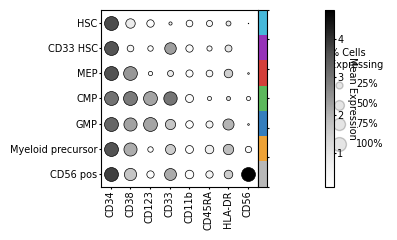

In [13]:
# Make a dot plot to describe the expession of molecules in each CD34+ subset

cell_types = ['HSC',  'CD33 HSC', 'MEP', 'CMP',  'GMP', 'Myeloid precursor',    'CD56 pos', ]

markers = ['CD34', 'CD38',  'CD123', 'CD33', 
      'CD11b',  'CD45RA', 'HLA-DR', 'CD56']



fig, ax = create_flow_dotplot(cells, markers, cell_types, expression_matrix, 
                             percent_matrix, color_table_dict, figsize=(4.0, 2.5),
    dot_scale= 1, )


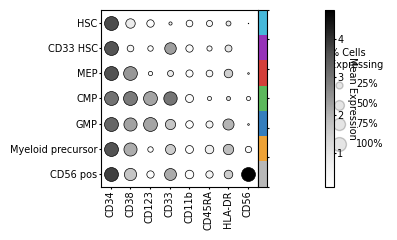

In [14]:
fig

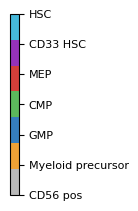

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def plot_colorbar_only(cell_types, color_table_dict, figsize=(2, 6)):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Hide the main axis
    ax.set_visible(False)
    
    # Create colormap for cell types
    cell_type_colors = [color_table_dict[ct] for ct in cell_types]
    cell_type_colors_reversed = cell_type_colors[::-1]  # Reverse if needed
    cell_type_cmap = ListedColormap(cell_type_colors_reversed)
    
    # Create a mappable for the cell type colorbar
    sm = plt.cm.ScalarMappable(cmap=cell_type_cmap, 
                               norm=plt.Normalize(vmin=0, vmax=len(cell_types)-1))
    sm.set_array([])
    
    # Create the colorbar
    colorbar = plt.colorbar(sm, ax=ax, shrink=1.0, aspect=20)
    colorbar.set_ticks(range(len(cell_types)))
    colorbar.set_ticklabels(cell_types[::-1])  # Reverse labels to match colors
    colorbar.ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    return fig, colorbar

# Plot the colorbar
fig, cbar = plot_colorbar_only(cell_types, color_table_dict)
plt.show()

#fig.savefig('../results/cd34_umap_cell_type_colorbar.pdf')

In [16]:
cells.columns

Index(['V1', '209Bi_CD45', 'Center', '161Dy_CD274_PDL1', '162Dy_CD80',
       'Event_length', '157Gd', '113In_CD45', '191Ir_DNA1', '193Ir_DNA2',
       '175Lu_STAT1_PE', '104Pd_CD45', '106Pd_CD45', '108Pd_CD45',
       '110Pd_CD45', '141Pr_CD196_CCR6', '194Pt_Cisplatin1',
       '195Pt_Cisplatin2', '147Sm_NKG2DFc_Cy5', '159Tb_CD90', '89Y_CD45',
       'Time', 'FileName', 'FileNo', 'Date', 'Patient_ID', 'Timepoint',
       'Batch_Control', 'Reference', 'Batch_Control_Type', 'Healthy',
       'Disease', 'Batch', '7_month_response', '12_month_response', 'CD117',
       'CD172ab_SIRPab', 'CD34', 'CD38', 'Ki67', 'CD3', 'CD123', 'CD68',
       'CD303', 'CD279_PD1', 'CD33', 'CD14', 'CD16', 'CD11c', 'CD19', 'CD64',
       'CD4', 'CD1c', 'CD11b', 'LILRB4_FITC', 'CD66b', 'CD45RA', 'CD40',
       'CD141', 'CD47_Biotin', 'HLA-DR', 'CD56', 'Alignment_MC_fineAlign',
       'FlowSOM_cluster', 'FlowSOM_metacluster', 'UMAP_X', 'UMAP_Y',
       'cell_type'],
      dtype='object')

In [36]:
cells['FileName']

1         P08_C1_D8_Myeloid_Panel
2         P08_C1_D8_Myeloid_Panel
3         P08_C1_D8_Myeloid_Panel
4         P08_C1_D8_Myeloid_Panel
5         P08_C1_D8_Myeloid_Panel
                   ...           
13790    Control_11_Myeloid_Panel
13791    Control_11_Myeloid_Panel
13792    Control_11_Myeloid_Panel
13793    Control_11_Myeloid_Panel
13794    Control_11_Myeloid_Panel
Name: FileName, Length: 13794, dtype: object